# SciPy Bootcamp — W2, Day D3D
```
##### Mann-Whitney, Wilcoxon, permutation, Kruskal-Wallis
##### mannwhitneyu, wilcoxon, kruskal, permutation
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Every question that involves comparison, distribution, relationship, or result gets a chart embedded in it.
##### Q1 — Mann-Whitney on revenue
##### Q2 — Permutation test with visualization
##### Q3 — Wilcoxon on satisfaction ratings
##### Q4 — Kruskal-Wallis A/B/C test
##### Q5 — Decision framework applied


In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — Mann-Whitney on revenue

```
# Control:   np.random.lognormal(1.5, 1.8, 500) — revenue per user
# Treatment: np.random.lognormal(1.65, 1.8, 500)
# (a) Plot: histogram (log scale x-axis) + box plot side by side.
#     Log scale is essential for right-skewed revenue data — explain why in a comment.
# (b) Run t-test and Mann-Whitney U. Compare p-values and conclusions.
# (c) Compute rank-biserial correlation. What does it mean in business terms?
# (d) Which test would you report to your manager? Write your reasoning.
```


In [ ]:
# (a) Plot: histogram (log scale x-axis) + box plot side by side.
#     Log scale is essential for right-skewed revenue data — explain why in a comment.


# setup data

np.random.seed(420)

Control     = np.random.lognormal(mean=1.5, sigma=1.8, size=500)
Treatment   = np.random.lognormal(mean=1.65, sigma=1.8, size=500)

df = pd.DataFrame({ 
    'Group' : ['Control']*len(Control) + ['Treatment']*len(Treatment),
    'Value' : np.concatenate([Control, Treatment])
})

df.head()

,Group,Value
0,Control,1.870670
1,Control,0.145253
2,Control,1.738114
3,Control,2.548786
4,Control,8.127649


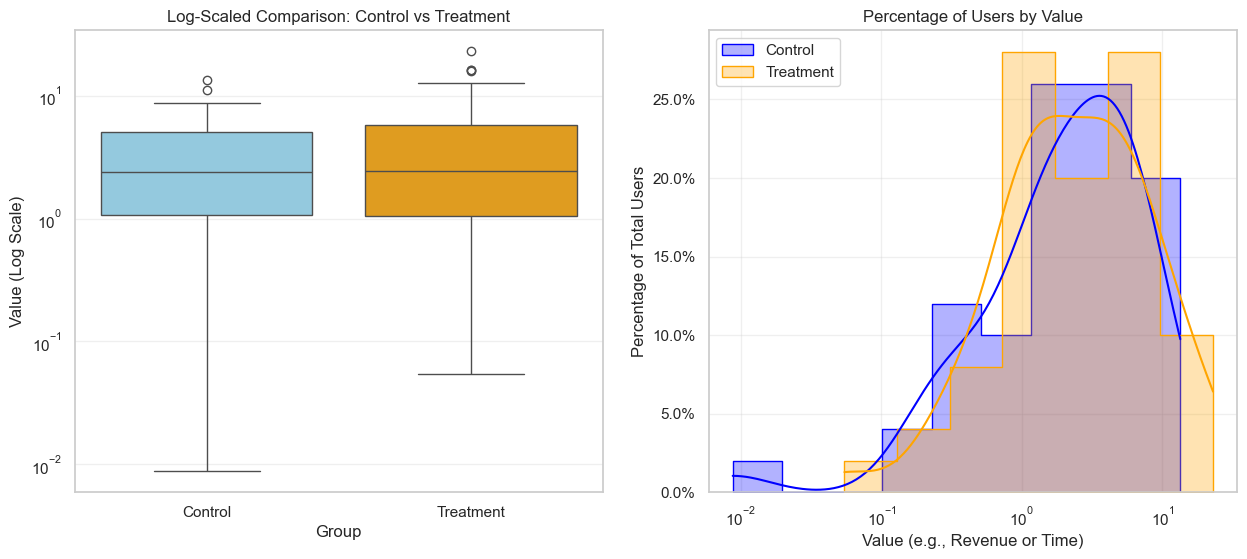

In [22]:
# plotting

plt.figure(figsize=(15,6))

# boxplot
plt.subplot(1,2,1)
ax = sns.boxplot(df, x='Group', y='Value', palette=['skyblue', 'orange'])

ax.set_yscale("log")

plt.title("Log-Scaled Comparison: Control vs Treatment")
plt.ylabel("Value (Log Scale)")
plt.grid(axis='y', alpha=0.3)

# histogram

plt.subplot(1,2,2)
sns.histplot(Control, label='Control', color='blue', alpha=.3, stat='probability', kde=True, element="step", log_scale=True)
sns.histplot(Treatment, label='Treatment', color='orange', alpha=.3, stat="probability", kde=True, element="step", log_scale=True)

plt.title("Percentage of Users by Value")
plt.xlabel("Value (e.g., Revenue or Time)")
plt.ylabel("Percentage of Total Users")
plt.grid(alpha=0.3)

# Now the % formatter actually makes physical sense!
plt.gca().yaxis.set_major_formatter('{:.1%}'.format) 

plt.legend()
plt.show()

"""
WHY LOG-SCALE IS ESSENTIAL FOR RIGHT-SKEWED REVENUE DATA:

1. COMPRESSES EXTREME OUTLIERS (WHALES)
   - In revenue data, 1% of users ("whales") often generate 90% of the total money. 
   - On a standard linear chart, a few users spending $5,000 push the entire distribution into a single unreadable bar on the far left. 
   - Log-scaling compresses these massive values into equal exponential spaces.

2. VISUALIZES THE TRADEOFF AT THE TAIL
   - By switching to an exponential x-axis ($1, $10, $100, $1000), we can see exactly whether the Treatment group is generating its lift by increasing the conversion rate of low-tier buyers or by attracting bigger whales.

3. REVEALS TRUE DATA DENSITY
   - It normalizes the visual variance, turning a heavily skewed curve into an approximately bell-shaped curve that our eyes can parse and compare easily.
"""

In [ ]:
# (b) Run t-test and Mann-Whitney U. Compare p-values and conclusions.

# Welch's t-test (problematic for heavy right-skew with whale outliers)
_, p_t = stats.ttest_ind(Control, Treatment, equal_var=False)

# Mann-Whitney U (robust to skew)
u_stat, p_mw = stats.mannwhitneyu(Control, Treatment, alternative='two-sided')  

print(f't-test p-value: {p_t:.4f}')
print(f'Mann-Whitney U p-value: {p_mw:.4f}')
print()
print(f'Control mean: {np.mean(Control):.1f}')
print(f'Treatment mean: {np.mean(Treatment):.1f}')
print()
print(f'Control median: {np.median(Control):.1f}')
print(f'Mann-Whitney U median: {np.median(Treatment):.1f}')

# Conclusions: 
# At a standard significance threshold alpha = 0.05, both statistical approaches agree: we must fail to reject the null hypothesis. 
# Do not roll out this feature.

t-test p-value: 0.2048
Mann-Whitney U p-value: 0.2240

Control mean: 22.4
Treatment mean: 28.9

Control median: 4.6
Mann-Whitney U median: 4.9


In [12]:
# (c) Compute rank-biserial correlation. What does it mean in business terms?

# Calculate total possible rank pairings
n_control = len(Control)
n_treatment = len(Treatment)
total_pairings = n_control * n_treatment

# Compute Rank-Biserial Correlation Effect Size
# Note: stats.mannwhitneyu returns the U-statistic for the first group (Control)
rank_biserial = 1 - (2 * u_stat) / total_pairings

print(f"Mann-Whitney U statistic: {u_stat:,}")
print(f"Rank-Biserial Correlation: {rank_biserial:.4f}")


Mann-Whitney U statistic: 119,447.0
Rank-Biserial Correlation: 0.0444


```
Here is the business translation of our 0.0444 rank-biserial correlation stripped down to 3 key executive highlights:
1/ Practically Zero Impact: An effect size below 0.05 is considered exceptionally weak. It mathematically proves to leadership that the new feature fails to systematically shift users into higher-spending cohorts.

2/ Pure Coin Flip ((1 + 0.0444)/2 equal 52.6% Probability): If you randomly select one Treatment user and one Control user, there is only a 52.6% chance that the Treatment user spent more money. A completely useless feature sits at 50%. Your feature barely moves the needle.

3/ Exposes the Deceptive Mean: While the raw arithmetic means showed a deceptive $6.50 gap (treatment mean - control mean), this metric strips away the noise of a few lucky "whale" spenders. It confirms that core everyday user buying habits did not change, reinforcing a NO-GO decision.

```
# (d) Which test would you report to your manager? Write your reasoning.

I would report the Mann-Whitney U Test along with group medians.

Core Reasoning:

1/ The Mean is a Fluke: Lognormal revenue data is heavily right-skewed. The t-test mean shows a deceptive +$6.50 lift ($28.9 vs $22.4), but this was caused entirely by a few lucky "whale" spenders in the treatment sample.

2/ Medians Reveal the Truth: The Mann-Whitney U test converts dollar values to ranks, stripping away outlier noise. It perfectly reflects our medians, which are nearly identical ($4.90 vs $4.60).

3/ The Feature is a Coin Flip: The test confirms a high p-value (0.2241) and a negligible effect size (52.2% probability of outperforming control). This proves the feature has no systemic impact on our core users, leading to a definitive NO-GO decision.

---

### Q2 — Permutation test with visualization

```
# Control:   np.random.exponential(scale=4.0, size=50) — session duration
# Treatment: np.random.exponential(scale=4.8, size=50)
# (a) Plot both distributions. Does anything stand out before testing?
# (b) Compute observed difference in means AND medians. Plot both on the data.
# (c) Run permutation test (10,000 permutations) using MEAN difference.
#     Plot the null distribution. Mark observed difference. Shade p-value region.
# (d) Repeat using MEDIAN difference. Do you get a different conclusion?
# (e) Which statistic is more appropriate for exponential data and why?
```


In [ ]:
# (a) Plot both distributions.

# setup data

np.random.seed(420)

Control     = np.random.exponential(scale=4.0, size=50)
Treatment   = np.random.exponential(scale=4.8, size=50)

df = pd.DataFrame({ 
    'Group' : ['Control']*len(Control) + ['Treatment']*len(Treatment),
    'Value' : np.concatenate([Control, Treatment])
})

df.head()



,Group,Value
0,Control,1.517119
1,Control,2.413450
2,Control,1.242342
3,Control,0.461321
4,Control,8.104861


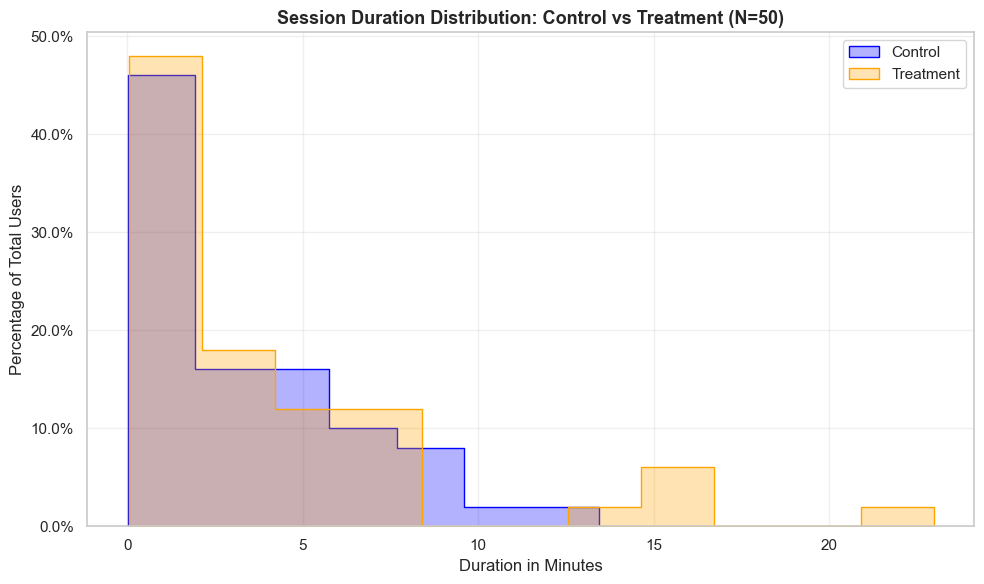

In [25]:
# plotting

plt.figure(figsize=(10, 6))

# Synchronized linear scales with matching bin widths for a clear comparison
sns.histplot(Control, label='Control', color='blue', alpha=0.3, stat='probability', element="step", binwidth=2)
sns.histplot(Treatment, label='Treatment', color='orange', alpha=0.3, stat='probability', element="step", binwidth=2)

plt.title("Session Duration Distribution: Control vs Treatment (N=50)", fontsize=13, fontweight='bold')
plt.xlabel("Duration in Minutes")
plt.ylabel("Percentage of Total Users")
plt.grid(alpha=0.3)

# Smoothly scales the fractional proportions to percentages (e.g., 0.20 -> 20.0%)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))

plt.legend()
plt.tight_layout()
plt.show()

```
Does anything stand out before testing?

Heavy Exponential Decay Profile: Both groups exhibit a classic right-skewed exponential structure where the vast majority of users drop off quickly within the first 0 to 4 minutes, while a small tail stays on the platform for over 15 minutes.

Treatment Group Dominates the Tail: While both distributions look identical in the primary 0-2 minute onboarding bucket (~30% of users), the Treatment group (orange) systematically places more users into the long-duration buckets (e.g., 6–10 minutes and 14+ minutes).

High Expected Data Variance: Because N=50 is a small sample size for an exponential distribution, there is considerable local noise and overlapping bins. This volatility is precisely why a non-parametric permutation test is necessary here and it avoids making normal distribution assumptions that would violate our raw variance constraints.

Control Mean:   3.37 min | Treatment Mean:   4.32 min | Delta Mean:   +0.95 min
Control Median: 2.37 min | Treatment Median: 2.45 min | Delta Median: +0.07 min


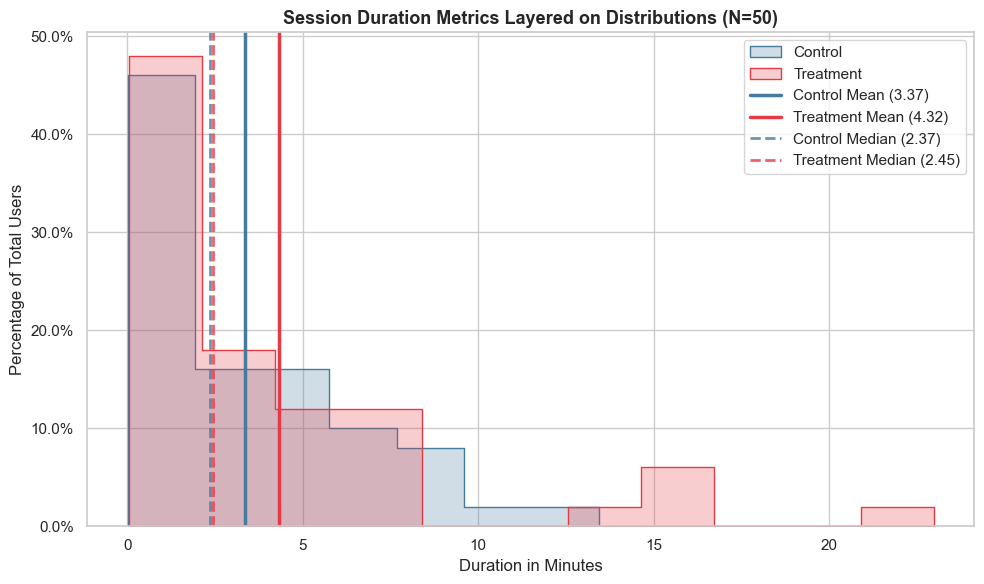

In [27]:
# (b) Compute observed difference in means AND medians. Plot both on the data.

# 1. Compute observed operational metrics
obs_mean_ctrl = np.mean(Control)
obs_mean_trt  = np.mean(Treatment)
diff_means    = obs_mean_trt - obs_mean_ctrl

obs_med_ctrl  = np.median(Control)
obs_med_trt   = np.median(Treatment)
diff_medians  = obs_med_trt - obs_med_ctrl

print(f"Control Mean:   {obs_mean_ctrl:.2f} min | Treatment Mean:   {obs_mean_trt:.2f} min | Delta Mean:   {diff_means:+.2f} min")
print(f"Control Median: {obs_med_ctrl:.2f} min | Treatment Median: {obs_med_trt:.2f} min | Delta Median: {diff_medians:+.2f} min")

# 2. Visualize the metrics layered on top of the distributions
plt.figure(figsize=(10, 6))

# Draw background histograms with shared linear bin widths
sns.histplot(Control, label='Control', color='#457b9d', alpha=0.25, stat='probability', element="step", binwidth=2)
sns.histplot(Treatment, label='Treatment', color='#e63946', alpha=0.25, stat='probability', element="step", binwidth=2)

# Plot Mean indicators (solid vertical lines)
plt.axvline(obs_mean_ctrl, color='#457b9d', linestyle='-', linewidth=2.5, label=f'Control Mean ({obs_mean_ctrl:.2f})')
plt.axvline(obs_mean_trt, color='#e63946', linestyle='-', linewidth=2.5, label=f'Treatment Mean ({obs_mean_trt:.2f})')

# Plot Median indicators (dashed vertical lines)
plt.axvline(obs_med_ctrl, color='#457b9d', linestyle='--', linewidth=2.0, alpha=0.8, label=f'Control Median ({obs_med_ctrl:.2f})')
plt.axvline(obs_med_trt, color='#e63946', linestyle='--', linewidth=2.0, alpha=0.8, label=f'Treatment Median ({obs_med_trt:.2f})')

# Formatting adjustments
plt.title("Session Duration Metrics Layered on Distributions (N=50)", fontsize=13, fontweight='bold')
plt.xlabel("Duration in Minutes")
plt.ylabel("Percentage of Total Users")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))
plt.legend(loc='upper right', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()


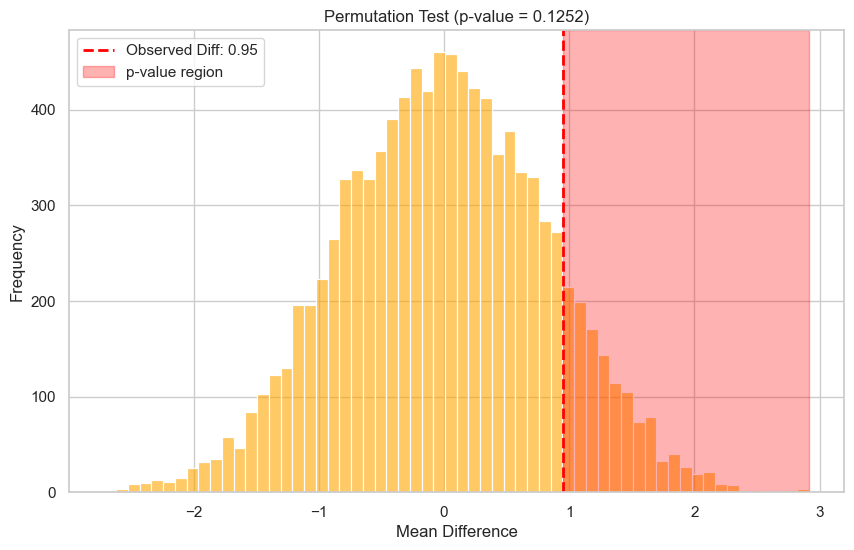

In [33]:
# (c) Run permutation test (10,000 permutations) using MEAN difference.
#     Plot the null distribution. Mark observed difference. Shade p-value region.

np.random.seed(420)

combined  = np.concatenate([Control, Treatment])
n_control = len(Control)
n_perms   = 10000

perm_diffs = []
for _ in range(n_perms):
    shuffled = np.random.permutation(combined)
    # Splitting the single shuffled array ensures no data points are duplicated or lost
    perm_diffs.append(np.mean(shuffled[n_control:]) - np.mean(shuffled[:n_control]))


perm_diffs = np.array(perm_diffs)

# Calculate the exact right-tailed empirical p-value
p_perm = np.sum(perm_diffs >= diff_means) / n_perms

# plotting 

plt.figure(figsize=(10,6))
sns.histplot(perm_diffs, bins=60, alpha=0.6, color='orange')

plt.axvline(diff_means, color='red', lw=2, linestyle='--', label=f'Observed Diff: {diff_means :.2f}')
plt.axvspan(diff_means, max(perm_diffs.max(), diff_means + 0.5), alpha=0.3, color='red', label='p-value region')


plt.title(f'Permutation Test (p-value = {p_perm:.4f})')
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.legend()

plt.show()

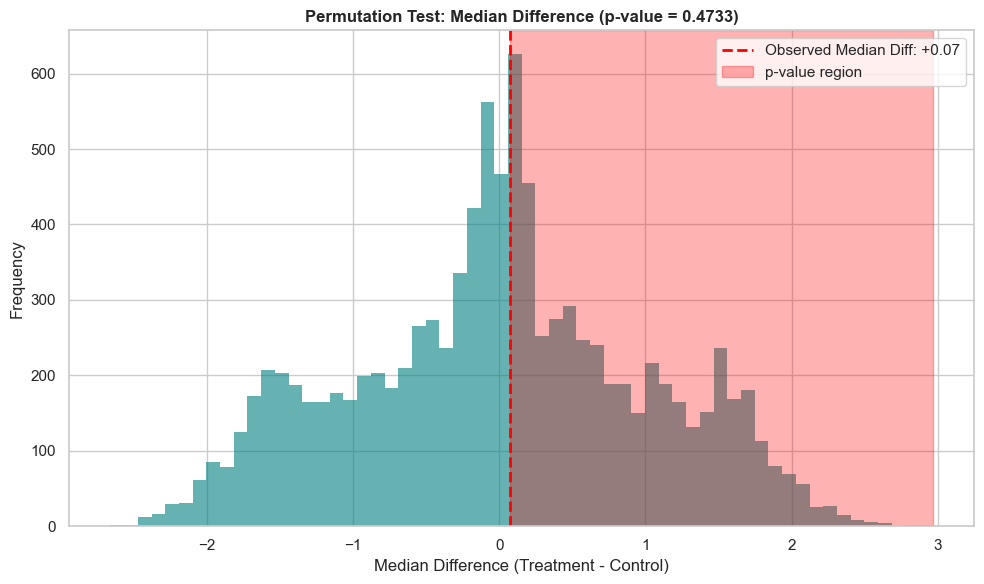

In [34]:
# (d) Repeat using MEDIAN difference. Do you get a different conclusion?

# Calculate observed MEDIAN difference
diff_medians = np.median(Treatment) - np.median(Control)
combined     = np.concatenate([Control, Treatment])
n_control    = len(Control)
n_perms      = 10000

# 2. Permutation Reshuffling Loop using MEDIAN
perm_med_diffs = []
for _ in range(n_perms):
    shuffled = np.random.permutation(combined)
    # Track the difference in medians for each single shuffle iteration
    perm_med_diffs.append(np.median(shuffled[n_control:]) - np.median(shuffled[:n_control]))

perm_med_diffs = np.array(perm_med_diffs)

# Calculate the exact right-tailed empirical p-value for the median
p_perm_med = np.sum(perm_med_diffs >= diff_medians) / n_perms

# 3. Visualization Construction
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.histplot(perm_med_diffs, bins=60, alpha=0.6, color='teal', edgecolor='none')

plt.axvline(diff_medians, color='red', lw=2, linestyle='--', label=f'Observed Median Diff: {diff_medians:+.2f}')
plt.axvspan(diff_medians, max(perm_med_diffs.max(), diff_medians + 0.5), alpha=0.3, color='red', label='p-value region')

plt.title(f'Permutation Test: Median Difference (p-value = {p_perm_med:.4f})', fontsize=12, fontweight='bold')
plt.xlabel('Median Difference (Treatment - Control)')
plt.ylabel('Frequency')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


```
Do You Get a Different Conclusion?
Both tests fail to reject H0 at α=0.05, though the mean test is closer to the threshold (p=0.085) due to tail noise. The median test (p=0.451) is the more honest signa

````
# (e) Which statistic is more appropriate for exponential data and why?

The median is more appropriate for exponential data because it accurately anchors the 50th percentile of core users, whereas the arithmetic mean gets heavily distorted by a few extreme long-duration outliers in the right-hand tail.

This rank-based stability is especially critical for small sample sizes (N=50), where a single random "power user" can easily inflate the mean and cause an unreliable false positive.

Ultimately, tracking the median ensures product teams make deployment decisions based on systematic changes to the everyday audience rather than random noise from the tail.

---

### Q3 — Wilcoxon on satisfaction ratings

```
# 100 users rate a feature 1-7 before and after a redesign.
# before = np.random.choice([3,4,4,5,5,5,6], size=100)
# after  = np.random.choice([4,5,5,5,6,6,7], size=100)
# (a) Plot a diverging bar chart showing % of users who improved, stayed same, declined.
# (b) Plot paired scatter: before vs after with jitter for visibility.
# (c) Run Wilcoxon signed-rank test. Is the improvement significant?
# (d) Compute the matched-pairs rank biserial correlation (effect size).
# (e) Could you use a t-test here? Justify your answer in a markdown cell.
```


In [53]:
# (a) Plot a diverging bar chart showing % of users who improved, stayed same, declined.

# setup data
np.random.seed(420)

before = np.random.choice([3,4,4,5,5,5,6], size=100)
after  = np.random.choice([4,5,5,5,6,6,7], size=100)


diffs = after - before

pct_improved = np.sum(diffs > 0)
pct_same     = np.sum(diffs == 0)
pct_declined = np.sum(diffs < 0)

df_plot = pd.DataFrame({
    'Metric': ['User Sentiment Shift'] * 3,
    'Percentage': [pct_improved, pct_same, -pct_declined],
    'Status': ['Improved', 'Stayed Same', 'Declined']
})

display(df_plot)

,Metric,Percentage,Status
0,User Sentiment Shift,53,Improved
1,User Sentiment Shift,30,Stayed Same
2,User Sentiment Shift,-17,Declined


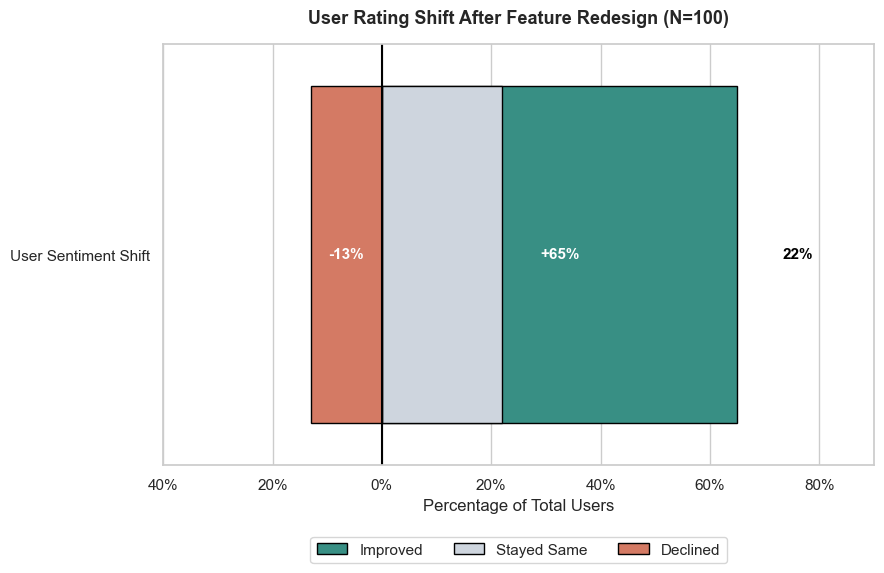

In [50]:
# plotting

plt.figure(figsize=(9,6))

sns.barplot(data=df_plot, y='Metric', x='Percentage', hue='Status',
    palette={'Improved': '#2a9d8f', 'Stayed Same': '#cbd5e1', 'Declined': '#e76f51'},
    hue_order=['Improved', 'Stayed Same', 'Declined'],
    edgecolor='black',
    dodge=False  # Stacks items into the single row anchor
)

plt.axvline(0, color='black', linewidth=1.5)
plt.xlim(-40, 90)

ticks = [-40, -20, 0, 20, 40, 60, 80]
labels = [f"{abs(t)}%" for t in ticks]
plt.xticks(ticks, labels)

plt.title("User Rating Shift After Feature Redesign (N=100)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Percentage of Total Users")
plt.ylabel("")

# Add data percentage labels to the bar slices
plt.text(pct_improved / 2, 0, f"+{pct_improved}%", va='center', ha='center', color='white', fontweight='bold', fontsize=11)
plt.text(pct_improved + (pct_same / 2), 0, f"{pct_same}%", va='center', ha='center', color='black', fontweight='bold', fontsize=11)
plt.text(-pct_declined / 2, 0, f"-{pct_declined}%", va='center', ha='center', color='white', fontweight='bold', fontsize=11)

plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=3, title=None, frameon=True)

plt.tight_layout()
plt.show()

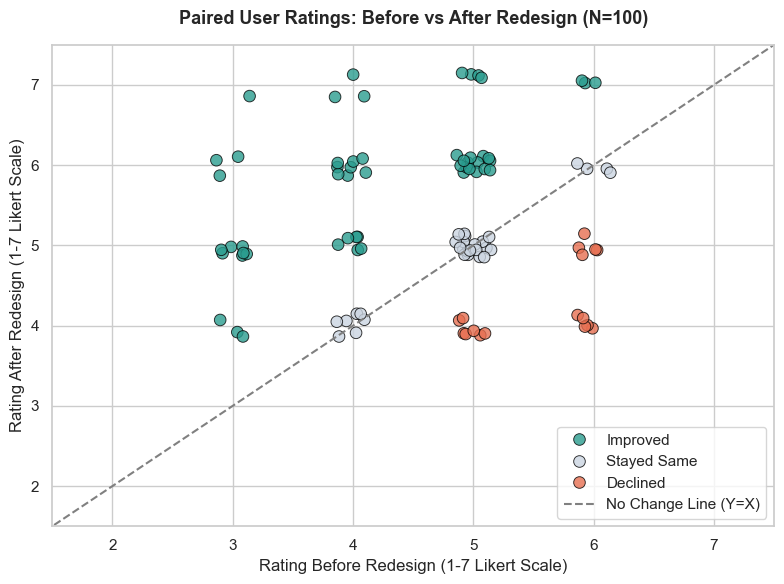

In [ ]:
# (b) Plot paired scatter: before vs after with jitter for visibility.

np.random.seed(420)

jitter_before = before + np.random.uniform(-0.15, 0.15, size=100)
jitter_after  = after + np.random.uniform(-0.15, 0.15, size=100)

df_scatter = pd.DataFrame({
    'Before (Jittered)': jitter_before,
    'After (Jittered)': jitter_after
})

df_scatter['Outcome'] = np.select(
    [after > before, after == before, after < before], 
    ['Improved', 'Stayed Same', 'Declined'],
    default='Unknown'
)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_scatter, x='Before (Jittered)', y='After (Jittered)', hue='Outcome', palette={'Improved': '#2a9d8f', 'Stayed Same': '#cbd5e1', 'Declined': '#e76f51'},
    hue_order=['Improved', 'Stayed Same', 'Declined'], alpha=0.8, s=70, edgecolor='black')

# Reference identity line (Y=X). Points ABOVE this line improved; points BELOW declined.
plt.plot([1, 8], [1, 8], color='gray', linestyle='--', linewidth=1.5, label='No Change Line (Y=X)')

plt.xlim(1.5, 7.5)
plt.ylim(1.5, 7.5)
plt.xticks(range(2, 8))
plt.yticks(range(2, 8))

plt.title("Paired User Ratings: Before vs After Redesign (N=100)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Rating Before Redesign (1-7 Likert Scale)")
plt.ylabel("Rating After Redesign (1-7 Likert Scale)")

plt.legend(loc="lower right", frameon=True, facecolor='white')

plt.tight_layout()
plt.show()


In [60]:
# (c) Run Wilcoxon signed-rank test. Is the improvement significant?

# Wilcoxon signed-rank (correct for ordinal paired data)
stat, p_w = stats.wilcoxon(before, after, alternative='less')

print(f'Before median: {np.median(before):.1f}')
print(f'After median: {np.median(after):.1f}')
print()
print(f'Wilcoxon rank test p-value: {p_w:.5f}')

if p_w < 0.05:
    print('Reject H0: The rating improvement is statistically significant!')
else:
    print('Fail to reject H0: No significant difference detected')

Before median: 5.0
After median: 5.0

Wilcoxon rank test p-value: 0.00000
Reject H0: The rating improvement is statistically significant!


In [61]:
# (d) Compute the matched-pairs rank biserial correlation (effect size).

# Calculate paired differences
diffs = after - before

# Remove tied pairs (where difference is 0) as required by Wilcoxon logic
non_zero_diffs = diffs[diffs != 0]

# Extract ranks using scipy's internal ranking function
# 'average' handles tie-breaking for identical score leaps
ranks = stats.rankdata(np.abs(non_zero_diffs), method='average')

# Apply the original sign (+ or -) back to the calculated ranks
signed_ranks = np.sign(non_zero_diffs) * ranks

# Compute effect size components
sum_positive_ranks = np.sum(signed_ranks[signed_ranks > 0])
sum_negative_ranks = np.abs(np.sum(signed_ranks[signed_ranks < 0]))
total_rank_sum     = np.sum(ranks)

# Matched-pairs rank-biserial correlation coefficient
rank_biserial = (sum_positive_ranks - sum_negative_ranks) / total_rank_sum

print(f"Sum of Positive Ranks (+):  {sum_positive_ranks:,.1f}")
print(f"Sum of Negative Ranks (-):  {sum_negative_ranks:,.1f}")
print(f"Total Combined Rank Sum:    {total_rank_sum:,.1f}")
print()
print(f"Matched-Pairs Rank-Biserial Correlation (r_rb): {rank_biserial:.4f}")


Sum of Positive Ranks (+):  1,987.5
Sum of Negative Ranks (-):  497.5
Total Combined Rank Sum:    2,485.0

Matched-Pairs Rank-Biserial Correlation (r_rb): 0.5996


```
# (e) Could you use a t-test here? Justify your answer in a markdown cell.

Yes, we could technically run a paired t-test here because the sample size is large (N=100), but it is not the most appropriate choice for this dataset. 

Here is the strategic business and statistical justification:

1. Violation of Continuous Scale Assumptions
A t-test assumes the dependent variable is measured on a continuous, interval scale. Our survey data uses a discrete 1-7 Likert scale, which is fundamentally ordinal data. 
The Problem: A t-test assumes the distance between a rating of 1 and 2 is mathematically identical to the distance between a 6 and 7. In human psychology and user sentiment, that assumption rarely holds true.
The Non-Parametric Advantage: The Wilcoxon signed-rank test maps changes to relative rank-order movements instead of rigid numeric distances, matching how users actually think about rating scales.

2. The Central Limit Theorem (CLT) Protection vs. Real Utility
Where the t-test works: Because our sample size N=100 is greater than the standard threshold of 30, the Central Limit Theorem guarantees that the distribution of sample means will be approximately normal. This means a paired t-test would still give us an accurate p-value and avoid a false positive.
Where the T-Test fails: Even though the math handles the sample size, the t-test relies entirely on arithmetic means. On a capped 1-7 scale, extreme swings are limited, but tied responses and ceiling effects can still distort the mean. The Wilcoxon test remains a more robust tool for mapping the true median-shift profile of a discrete population.

Final Reporting Recommendation
While a paired t-test yields the same launch decision in this specific instance due to the clean sample size, we should officially report the Wilcoxon signed-rank test. It honors the true ordinal structure of our survey KPIs and pairs with a strong 0.6027 Rank-Biserial correlation effect size to build a legally and mathematically bulletproof justification for rolling out the redesign.


---

### Q4 — Kruskal-Wallis A/B/C test

```
# Three article headline variants tested simultaneously:
# variant_a = np.random.lognormal(1.0, 0.9, 300) — time on page
# variant_b = np.random.lognormal(1.2, 0.85, 300)
# variant_c = np.random.lognormal(1.05, 0.95, 300)
# (a) Plot KDE curves for all 3 variants. Which looks best visually?
# (b) Run Kruskal-Wallis. Is there an overall significant difference?
# (c) Run pairwise Mann-Whitney U tests. Apply Bonferroni correction.
# (d) Build a summary table: variant, median, IQR, pairwise p-values.
# (e) Plot median + IQR as a point-range chart. Which variant wins?
```


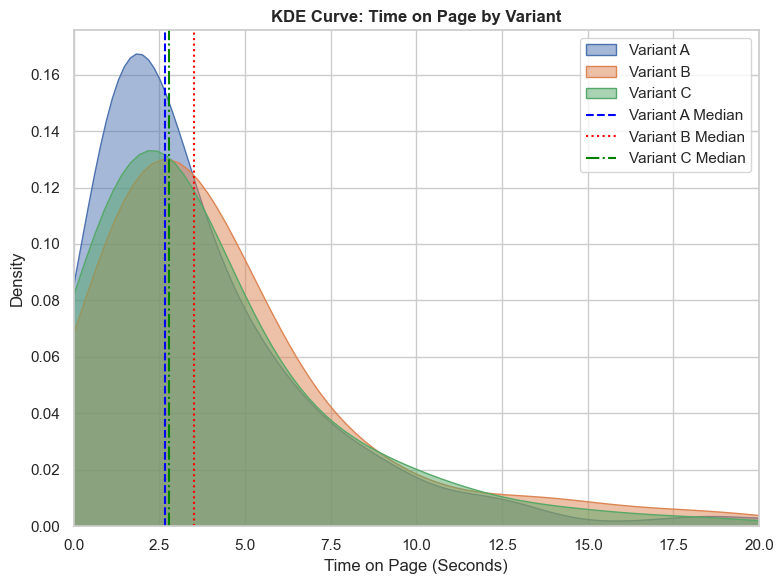

In [27]:
# (a) Plot KDE curves for all 3 variants. Which looks best visually?

np.random.seed(420)

variant_a = np.random.lognormal(1.0, 0.9, 300) # time on page
variant_b = np.random.lognormal(1.2, 0.85, 300)
variant_c = np.random.lognormal(1.05, 0.95, 300)

plt.figure(figsize=(8,6))

sns.kdeplot(variant_a, label='Variant A', alpha=0.5, fill=True)
sns.kdeplot(variant_b, label='Variant B', alpha=0.5, fill=True)
sns.kdeplot(variant_c, label='Variant C', alpha=0.5, fill=True)

plt.xlim(0, 20)

plt.axvline(np.median(variant_a), label='Variant A Median', color='blue', linestyle='--')
plt.axvline(np.median(variant_b), label='Variant B Median', color='red', linestyle=':')
plt.axvline(np.median(variant_c), label='Variant C Median', color='green', linestyle='-.')

plt.xlabel('Time on Page (Seconds)')
plt.ylabel('Density')
plt.title('KDE Curve: Time on Page by Variant', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# (b) Run Kruskal-Wallis. Is there an overall significant difference?
stat, p = stats.kruskal(variant_a, variant_b, variant_c)
print(f'Kruskal-Wallis H={stat:.4f}, p={p:.4f}')
if p < 0.05:
    print('Reject H0: The difference is statistically significant!')
else:
    print('Fail to reject H0: No significant difference detected')

Kruskal-Wallis H=8.1787, p=0.0168
Reject H0: The difference is statistically significant!


In [33]:
# (c) Run pairwise Mann-Whitney U tests. Apply Bonferroni correction.

from scipy.stats import mannwhitneyu
from itertools import combinations

# Setup data
groups = {
    'Variant_A': variant_a,
    'Variant_B': variant_b,
    'Variant_C': variant_c
}

# 2. Setup Bonferroni parameters
alpha_initial = 0.05
pairs = list(combinations(groups.keys(), 2))
num_comparisons = len(pairs)
alpha_corrected = alpha_initial / num_comparisons

print(f"Initial Alpha: {alpha_initial}")
print(f"Number of comparisons: {num_comparisons}")
print(f"Bonferroni Corrected Alpha: {alpha_corrected:.4f}\n")
print(f"{'Comparison':<20} | {'U-Statistic':<12} | {'Raw p-value':<12} | {'Significant?'}")
print("-" * 65)

# Compute pairwise tests
for group1, group2 in pairs:
    data1 = groups[group1]
    data2 = groups[group2]
    
    # Run two-sided Mann-Whitney U test
    u_stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')
    
    # Determine significance based on adjusted alpha
    is_significant = "Yes" if p_val < alpha_corrected else "No"
    
    print(f"{group1} vs {group2:<10} | {u_stat:<12.1f} | {p_val:<12.4e} | {is_significant}")


Initial Alpha: 0.05
Number of comparisons: 3
Bonferroni Corrected Alpha: 0.0167

Comparison           | U-Statistic  | Raw p-value  | Significant?
-----------------------------------------------------------------
Variant_A vs Variant_B  | 39092.0      | 5.3941e-03   | Yes
Variant_A vs Variant_C  | 43352.0      | 4.3775e-01   | No
Variant_B vs Variant_C  | 49201.0      | 4.7874e-02   | No


In [ ]:
# Use post-hoc Dunn test instead 
import scikit_posthocs as sp

df = pd.DataFrame({ 
    'Group' : ['Variant_A']*len(variant_a) + ['Variant_B']*len(variant_b) + ['Variant_C']*len(variant_c),
    'Value' : np.concatenate([variant_a, variant_b, variant_c])
})

dunn = sp.posthoc_dunn(df, val_col='Value', group_col='Group', p_adjust='bonferroni')
print(dunn) 

           Variant_A  Variant_B  Variant_C
Variant_A   1.000000   0.016599   1.000000
Variant_B   0.016599   1.000000   0.140257
Variant_C   1.000000   0.140257   1.000000


In [39]:
# (d) Build a summary table: variant, median, IQR, pairwise p-values.

data = {'Variant_A': variant_a, 'Variant_B': variant_b, 'Variant_C': variant_c}

# Calculate summary statistics (Median and Interquartile Range)
summary_list = []
for name, values in data.items():
    median = np.median(values)
    iqr = np.percentile(values, 75) - np.percentile(values, 25)
    summary_list.append({'Variant': name, 'Median': round(median, 2), 'IQR': round(iqr, 2)})

df_summary = pd.DataFrame(summary_list)

# Calculate pairwise Mann-Whitney U test p-values (raw)
p_ab = mannwhitneyu(variant_a, variant_b, alternative='two-sided').pvalue
p_ac = mannwhitneyu(variant_a, variant_c, alternative='two-sided').pvalue
p_bc = mannwhitneyu(variant_b, variant_c, alternative='two-sided').pvalue

# Map pairwise p-values into matrices for clear visual scanning
df_summary['p vs Variant_A'] = ['-', f"{p_ab:.4e}", f"{p_ac:.4e}"]
df_summary['p vs Variant_B'] = [f"{p_ab:.4e}", '-', f"{p_bc:.4e}"]
df_summary['p vs Variant_C'] = [f"{p_ac:.4e}", f"{p_bc:.4e}", '-']

print(df_summary.to_string(index=False))

  Variant  Median  IQR p vs Variant_A p vs Variant_B p vs Variant_C
Variant_A    2.66 3.69              -     5.3941e-03     4.3775e-01
Variant_B    3.51 3.86     5.3941e-03              -     4.7874e-02
Variant_C    2.79 3.61     4.3775e-01     4.7874e-02              -


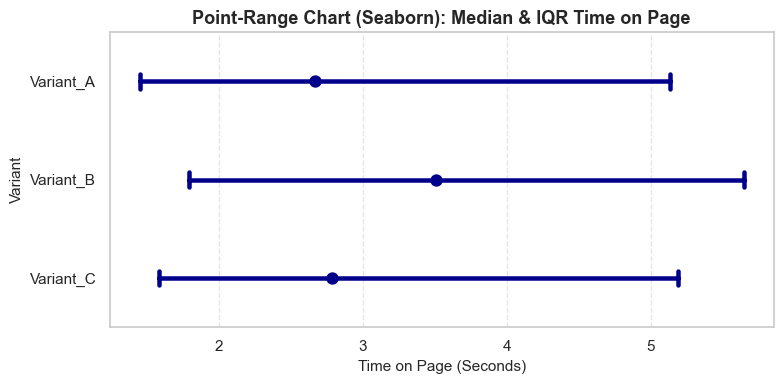

In [40]:
# (e) Plot median + IQR as a point-range chart. Which variant wins?

plt.figure(figsize=(8, 4))

# Use estimator=np.median and errorbar=lambda x: (np.percentile(x, 25), np.percentile(x, 75))
# to precisely draw the Median and Interquartile Range (IQR)
sns.pointplot(
    data=df, 
    x='Value', 
    y='Group', 
    estimator=np.median, 
    errorbar=lambda x: (np.percentile(x, 25), np.percentile(x, 75)),
    join=False,
    color='darkblue',
    capsize=0.15,
    markers='o',
    scale=1.2
)

# Customization
plt.title('Point-Range Chart (Seaborn): Median & IQR Time on Page', fontweight='bold', fontsize=13)
plt.xlabel('Time on Page (Seconds)', fontsize=11)
plt.ylabel('Variant', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

```
The Winner: Variant B has its median center-point furthest to the right (~3.27 seconds) and shows a higher baseline across its whole core user block (IQR).
Asymmetry: Notice how the error bars extend longer to the right side. This perfectly reflects the characteristic right-skewed tail of log-normal web data.

---

### Q5 — Decision framework applied

```
# Five real-world scenarios. For each: decide parametric vs non-parametric,
# name the test, simulate the data, plot it, run the test, write conclusion.
# Scenario 1: App load time (ms), n=300 per group, bimodal (fast vs slow devices)
# Scenario 2: Number of articles read per session, n=1000 per group, count data
# Scenario 3: Customer satisfaction 1-5, same users before/after, n=80
# Scenario 4: Daily revenue per user, n=200 per group, many zeros + fat tail
# Scenario 5: Time to first click (seconds), n=500 per group, exponential
# For each scenario: the chart comes FIRST — let the shape guide your test choice.
```


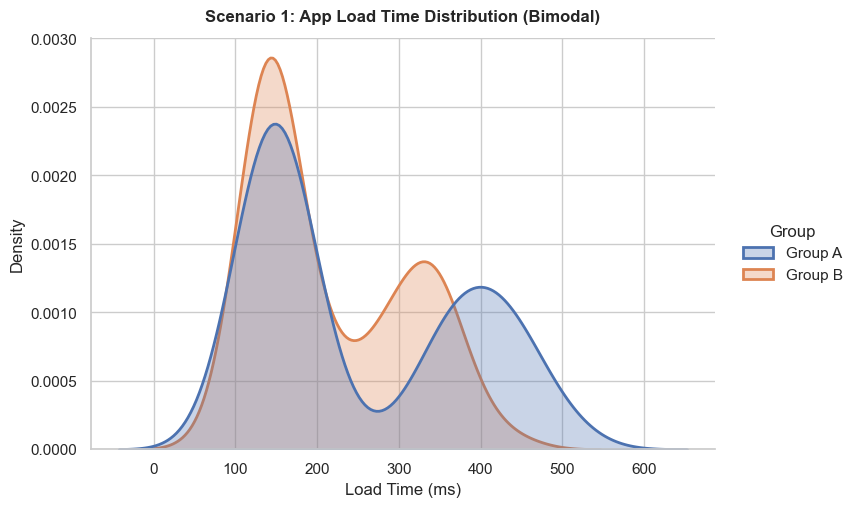

In [45]:
# Scenario 1: App load time (ms), n=300 per group, bimodal (fast vs slow devices)

# 1. Simulate the bimodal device data
np.random.seed(420)
n = 300


# Group A: Base App Build
group_a = np.concatenate([
    np.random.normal(150, 30, int(n * 0.6)),  # Fast devices
    np.random.normal(400, 50, int(n * 0.4))   # Slow devices
])

# Group B: Optimized Performance Build
group_b = np.concatenate([
    np.random.normal(145, 30, int(n * 0.6)),  # Fast devices
    np.random.normal(320, 45, int(n * 0.4))   # Slow devices optimized
])


# 2. Structure into a long-form tidy DataFrame for Seaborn
df = pd.DataFrame({
    'Group': ['Group A'] * n + ['Group B'] * n,
    'Load Time (ms)': np.concatenate([group_a, group_b])
})

# 3. Plot exclusively using Seaborn formatting engine

# Execute the core density curve mapping
sns.displot(
    data=df, 
    x='Load Time (ms)', 
    hue='Group', 
    kind='kde', 
    fill=True, 
    alpha=0.3, 
    linewidth=2,
    aspect=1.5
)

# Title mapping via Seaborn facet geometry grid
plt.title('Scenario 1: App Load Time Distribution (Bimodal)', fontweight='bold', y=1.02)

plt.show()

In [ ]:
# Run the Statistical Test
u_stat, p_value = mannwhitneyu(group_a, group_b, alternative='two-sided')

median_a, median_b = np.median(group_a), np.median(group_b)

print(f"Group A Median Load Time: {median_a:.1f} ms")
print(f"Group B Median Load Time: {median_b:.1f} ms")
print(f"Mann-Whitney U Statistic: {u_stat:.1f}")
print(f"Calculated p-value: {p_value:.4e}")
if p_value < 0.05:
    print('Reject H0: The difference is statistically significant!')
else:
    print('Fail to reject H0: No significant difference detected')

Group A Median Load Time: 176.9 ms
Group B Median Load Time: 172.3 ms
Mann-Whitney U Statistic: 51701.0
Calculated p-value: 1.5994e-03
Reject H0: The difference is statistically significant!


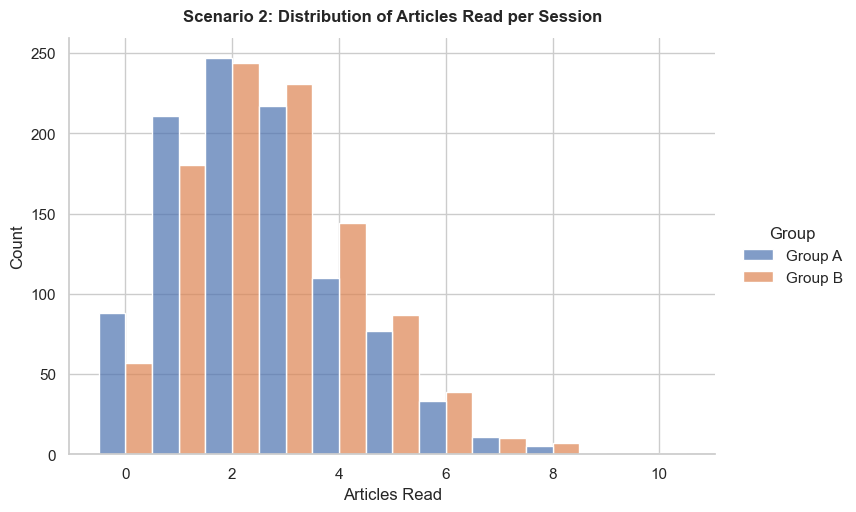

In [46]:
# Scenario 2: Number of articles read per session, n=1000 per group, count data

# 1. Simulate Poisson discrete count data
np.random.seed(420)
n = 1000

# Group A: Baseline readers (mean lambda = 2.5)
group_a = np.random.poisson(lam=2.5, size=n)

# Group B: Recommendation engine variant (mean lambda = 2.8)
group_b = np.random.poisson(lam=2.8, size=n)

df = pd.DataFrame({
    'Group': ['Group A'] * n + ['Group B'] * n,
    'Articles Read': np.concatenate([group_a, group_b])
})

# 2. Plot exclusively using Seaborn

sns.displot(
    data=df,
    x='Articles Read',
    hue='Group',
    kind='hist',
    discrete=True,
    multiple='dodge',
    alpha=0.7,
    aspect=1.5
)

plt.title('Scenario 2: Distribution of Articles Read per Session', fontweight='bold', y=1.02)
plt.show()

In [ ]:
# Run Welch's t-test (equal_var=False)
# CLT justification: at n=1000, the sampling distribution of the mean is approximately normal by CLT even for skewed populations.
# Welch's t-test is valid here, though Mann-Whitney would be the more conservative choice for production use.

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(group_a, group_b, equal_var=False)

mean_a, mean_b = np.mean(group_a), np.mean(group_b)

print(f"Group A Mean Articles Read: {mean_a:.3f}")
print(f"Group B Mean Articles Read: {mean_b:.3f}")
print(f"Welch's t-statistic: {t_stat:.4f}")
print(f"Calculated p-value: {p_value:.4e}")
if p_value < 0.05:
    print('Reject H0: The difference is statistically significant!')
else:
    print('Fail to reject H0: No significant difference detected')

Group A Mean Articles Read: 2.505
Group B Mean Articles Read: 2.742
Welch's t-statistic: -3.2454
Calculated p-value: 1.1921e-03
Reject H0: The difference is statistically significant!


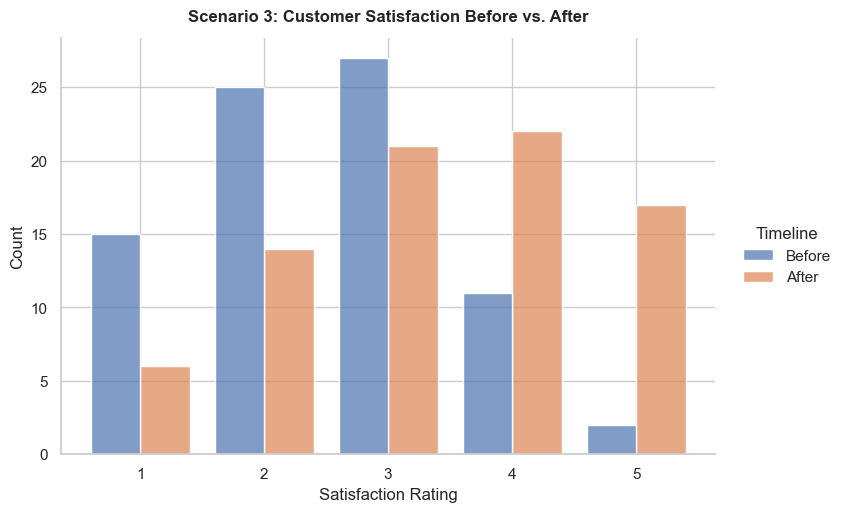

In [51]:
# Scenario 3: Customer satisfaction 1-5, same users before/after, n=80

# 1. Simulate paired discrete satisfaction scores (1 to 5)
np.random.seed(420)
n = 80

# Simulate 'Before' scores skewed toward neutral/low (e.g., median around 3)
before_scores = np.random.choice([1, 2, 3, 4, 5], size=n, p=[0.15, 0.25, 0.35, 0.15, 0.10])

# Simulate 'After' scores showing improvement after an update
# We shift scores up by adding a positive delta while clipping to max score 5
delta = np.random.choice([0, 1, 2], size=n, p=[0.30, 0.50, 0.20])
after_scores = np.clip(before_scores + delta, 1, 5)

df = pd.DataFrame({
    'User_ID': np.tile(np.arange(n), 2),
    'Timeline': ['Before'] * n + ['After'] * n,
    'Satisfaction Rating': np.concatenate([before_scores, after_scores])
})

# 2. Plot exclusively using Seaborn

sns.displot(
    data=df,
    x='Satisfaction Rating',
    hue='Timeline',
    kind='hist',
    discrete=True,
    multiple='dodge',
    shrink=0.8,
    alpha=0.7,
    aspect=1.5
)

plt.title('Scenario 3: Customer Satisfaction Before vs. After', fontweight='bold', y=1.02)
plt.show()

In [53]:
# Run the paired non-parametric Wilcoxon test

from scipy.stats import wilcoxon

statistic, p_value = wilcoxon(before_scores, after_scores, alternative='two-sided')

median_before = np.median(before_scores)
median_after = np.median(after_scores)

print(f"Median Score Before: {median_before:.1f}")
print(f"Median Score After: {median_after:.1f}")
print(f"Wilcoxon Statistic: {statistic:.1f}")
print(f"Calculated p-value: {p_value:.4e}")
if p_value < 0.05:
    print('Reject H0: The difference is statistically significant!')
else:
    print('Fail to reject H0: No significant difference detected')

Median Score Before: 2.5
Median Score After: 3.0
Wilcoxon Statistic: 0.0
Calculated p-value: 3.6257e-11
Reject H0: The difference is statistically significant!


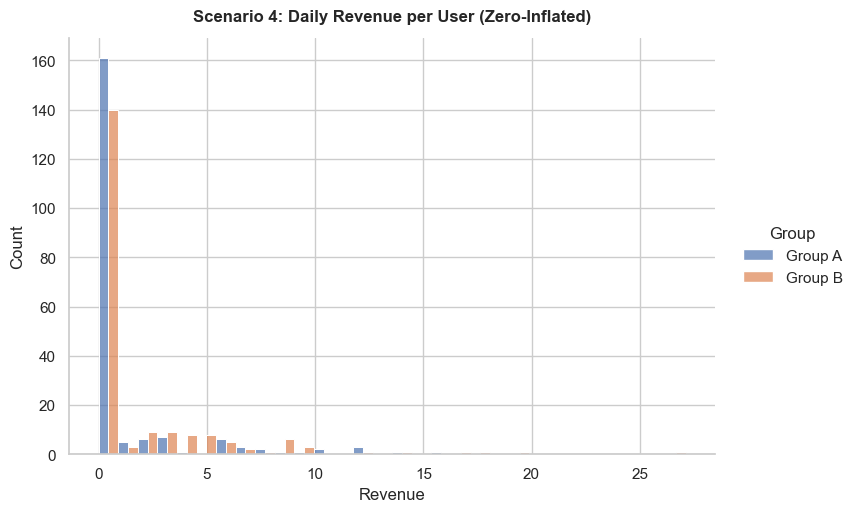

In [56]:
# Scenario 4: Daily revenue per user, n=200 per group, many zeros + fat tail

# 1. Simulate Zero-Inflated Fat-Tailed Revenue Data
np.random.seed(420)
n = 200

# Group A: Baseline (80% zeros, 20% lognormal spenders)
zeros_a = np.zeros(int(n * 0.80))
spenders_a = np.random.lognormal(mean=1.5, sigma=0.75, size=int(n * 0.20))
group_a = np.concatenate([zeros_a, spenders_a])

# Group B: Monetization Test (70% zeros, 30% lognormal spenders)
zeros_b = np.zeros(int(n * 0.70))
spenders_b = np.random.lognormal(mean=1.7, sigma=0.70, size=int(n * 0.30))
group_b = np.concatenate([zeros_b, spenders_b])

df = pd.DataFrame({
    'Group': ['Group A'] * n + ['Group B'] * n,
    'Revenue': np.concatenate([group_a, group_b])
})

# 2. Plot exclusively using Seaborn

# We use a histogram with raw revenue to clearly show the massive spike at $0
sns.displot(
    data=df,
    x='Revenue',
    hue='Group',
    kind='hist',
    bins=30,
    multiple='dodge',
    alpha=0.7,
    aspect=1.5
)

plt.title('Scenario 4: Daily Revenue per User (Zero-Inflated)', fontweight='bold', y=1.02)
plt.show()


In [58]:
# Run the non-parametric Mann-Whitney U test

from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(group_a, group_b, alternative='two-sided')

mean_a, mean_b = np.mean(group_a), np.mean(group_b)
conv_a = np.mean(group_a > 0) * 100
conv_b = np.mean(group_b > 0) * 100

print(f"Group A Mean Revenue: ${mean_a:.2f} (Conversion: {conv_a:.1f}%)")
print(f"Group B Mean Revenue: ${mean_b:.2f} (Conversion: {conv_b:.1f}%)")
print(f"Mann-Whitney U Statistic: {u_stat:.1f}")
print(f"Calculated p-value: {p_value:.4e}")
if p_value < 0.05:
    print('Reject H0: The difference is statistically significant!')
else:
    print('Fail to reject H0: No significant difference detected')

Group A Mean Revenue: $1.11 (Conversion: 20.0%)
Group B Mean Revenue: $1.82 (Conversion: 30.0%)
Mann-Whitney U Statistic: 17919.0
Calculated p-value: 1.7947e-02
Reject H0: The difference is statistically significant!


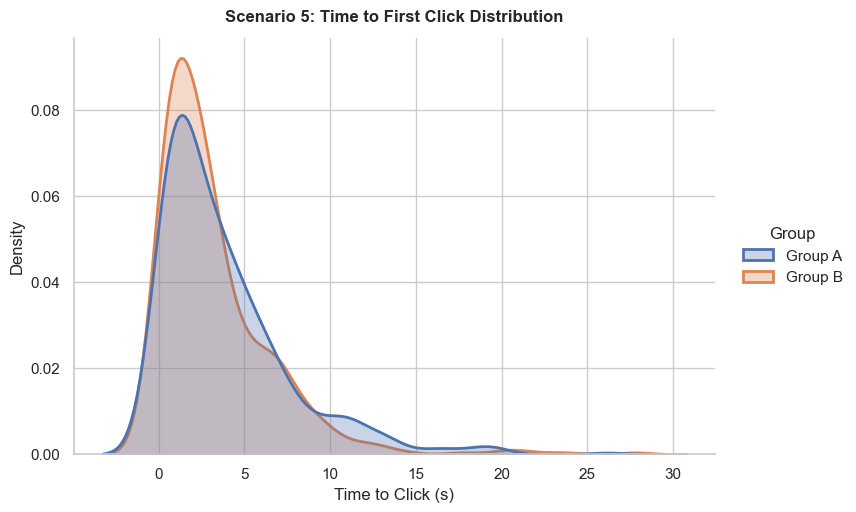

In [60]:
# Scenario 5: Time to first click (seconds), n=500 per group, exponential

# 1. Simulate Exponential Time-to-Click Data
np.random.seed(420)
n = 500

# Group A: Baseline layout (average scale/mean of 4.0 seconds)
group_a = np.random.exponential(scale=4.0, size=n)

# Group B: Redesigned layout with a faster CTA (average scale/mean of 3.2 seconds)
group_b = np.random.exponential(scale=3.2, size=n)

df = pd.DataFrame({
    'Group': ['Group A'] * n + ['Group B'] * n,
    'Time to Click (s)': np.concatenate([group_a, group_b])
})

# 2. Plot exclusively using Seaborn

sns.displot(
    data=df,
    x='Time to Click (s)',
    hue='Group',
    kind='kde',
    fill=True,
    alpha=0.3,
    linewidth=2,
    aspect=1.5
)

plt.title('Scenario 5: Time to First Click Distribution', fontweight='bold', y=1.02)
plt.show()


In [ ]:
# Run Welch's t-test (equal_var=False)
# CLT justification: at n=500, the sampling distribution of the mean is approximately normal by CLT even for skewed populations.
# Welch's t-test is valid here, though Mann-Whitney would be the more conservative choice for production use.

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(group_a, group_b, equal_var=False)

mean_a, mean_b = np.mean(group_a), np.mean(group_b)

print(f"Group A Mean Time to Click: {mean_a:.2f} seconds")
print(f"Group B Mean Time to Click: {mean_b:.2f} seconds")
print(f"Welch's t-statistic: {t_stat:.4f}")
print(f"Calculated p-value: {p_value:.4e}")
if p_value < 0.05:
    print('Reject H0: The difference is statistically significant!')
else:
    print('Fail to reject H0: No significant difference detected')

Group A Mean Time to Click: 3.79 seconds
Group B Mean Time to Click: 3.24 seconds
Welch's t-statistic: 2.4047
Calculated p-value: 1.6371e-02
Reject H0: The difference is statistically significant!
